# kSZ Pipeline — Convergence Results

All six convergence sweeps: coeval-direct (box-size, resolution, dz) and
stitched (box-size, resolution, angle-of-stitching). Commit-dependent --
re-run after any code change to confirm these are still current.

The angle-of-stitching plot is the most important one right now: it
directly tests whether the low-ell spike in stitched's D_ell is a
periodic-replication artifact (angle_deg=0 issue).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

PRODUCTS_DIR = "../../data/products"
PLOTS_DIR = "../../data/plots"

plt.rcParams.update({'font.family': 'serif', 'font.size': 12})

## Coeval-direct: box-size convergence

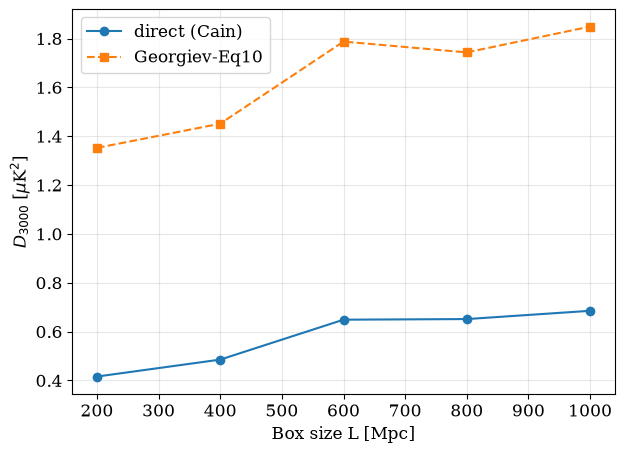

{'box200_N32': 0.41602336705913384, 'box400_N64': 0.48542232892321246, 'box600_N96': 0.6488536752377078, 'box800_N128': 0.6513940772689162, 'box1000_N160': 0.6852200988976951}


In [2]:
d = np.load(f"{PRODUCTS_DIR}/convergence_coeval_boxsize.npz")
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(d['x_values'], d['D3000_direct'], 'o-', label='direct (Cain)')
ax.plot(d['x_values'], d['D3000_georgiev'], 's--', label='Georgiev-Eq10')
ax.set_xlabel("Box size L [Mpc]"); ax.set_ylabel(r"$D_{3000}$ [$\mu$K$^2$]")
ax.legend(); ax.grid(alpha=0.3)
plt.show()
print(dict(zip(d['tags'], d['D3000_direct'])))

## Coeval-direct: resolution convergence

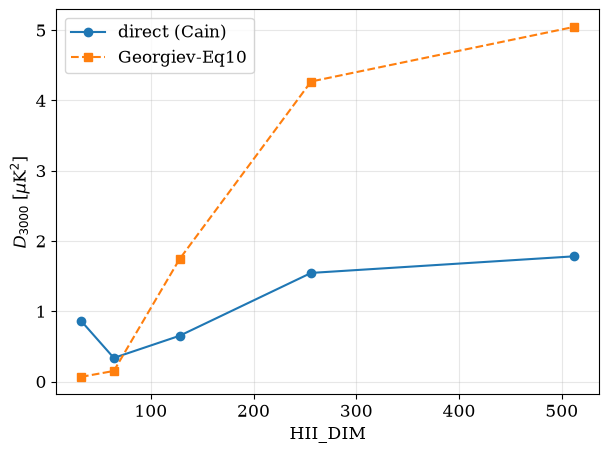

{'res32': 0.8659658839319405, 'res64': 0.33646633890126776, 'res128': 0.6513940772689162, 'res256': 1.5459692939323642, 'res512': 1.7821855081906282}


In [3]:
d = np.load(f"{PRODUCTS_DIR}/convergence_coeval_resolution.npz")
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(d['x_values'], d['D3000_direct'], 'o-', label='direct (Cain)')
ax.plot(d['x_values'], d['D3000_georgiev'], 's--', label='Georgiev-Eq10')
ax.set_xlabel("HII_DIM"); ax.set_ylabel(r"$D_{3000}$ [$\mu$K$^2$]")
ax.legend(); ax.grid(alpha=0.3)
plt.show()
print(dict(zip(d['tags'], d['D3000_direct'])))

## Coeval-direct: dz (redshift-sampling) convergence

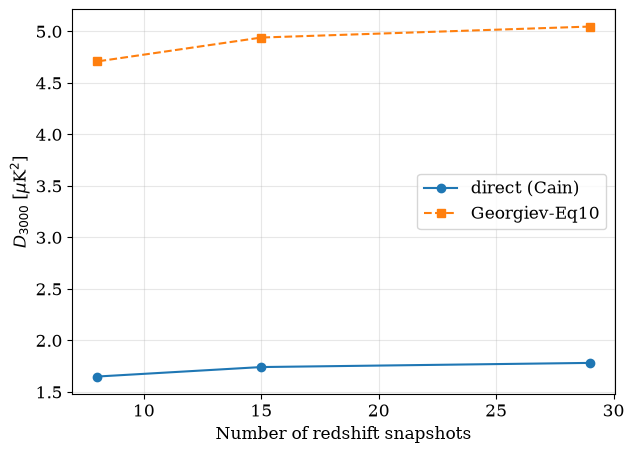

dz_multiples: [1 2 4]  n_z: [29 15  8]  D3000: [1.7821855  1.74183938 1.64964004]


In [4]:
d = np.load(f"{PRODUCTS_DIR}/convergence_dz_coeval.npz")
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(d['n_z'], d['D3000_direct'], 'o-', label='direct (Cain)')
ax.plot(d['n_z'], d['D3000_georgiev'], 's--', label='Georgiev-Eq10')
ax.set_xlabel("Number of redshift snapshots"); ax.set_ylabel(r"$D_{3000}$ [$\mu$K$^2$]")
ax.legend(); ax.grid(alpha=0.3)
plt.show()
print("dz_multiples:", d['dz_multiples'], " n_z:", d['n_z'], " D3000:", d['D3000_direct'])

## Stitched: box-size convergence

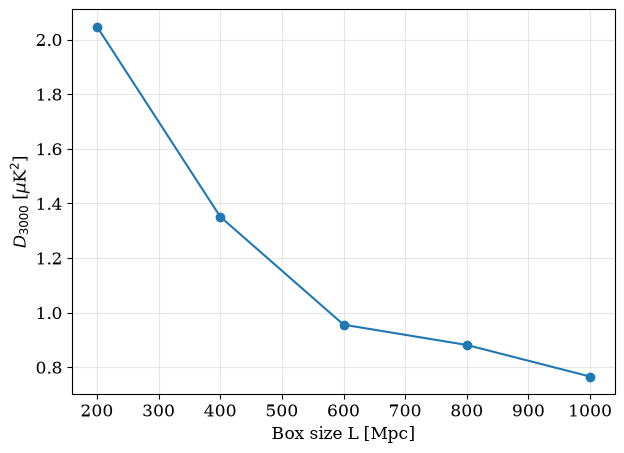

{'box200_N32': 2.0478372227478294, 'box400_N64': 1.3514201691498933, 'box600_N96': 0.9561500646137138, 'box800_N128': 0.8817289009345626, 'box1000_N160': 0.7661149185874634}


In [5]:
d = np.load(f"{PRODUCTS_DIR}/convergence_stitched_boxsize.npz")
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(d['x_values'], d['D3000'], 'o-', color='tab:blue')
ax.set_xlabel("Box size L [Mpc]"); ax.set_ylabel(r"$D_{3000}$ [$\mu$K$^2$]")
ax.grid(alpha=0.3)
plt.show()
print(dict(zip(d['tags'], d['D3000'])))

## Stitched: resolution convergence

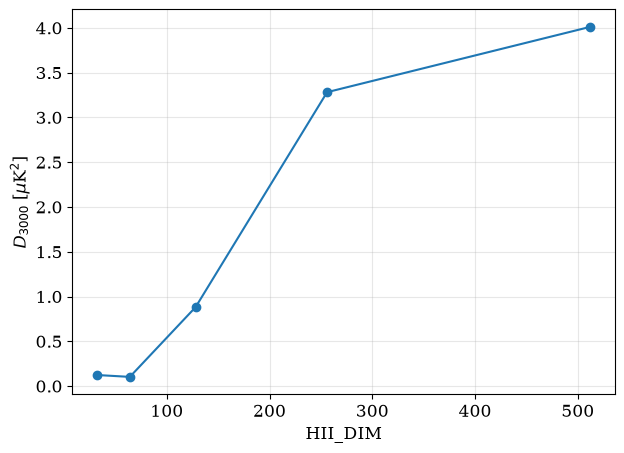

{'res32': 0.12402795484421997, 'res64': 0.10296794182558514, 'res128': 0.8817289009345626, 'res256': 3.282077342932589, 'res512': 4.011130100742262}


In [6]:
d = np.load(f"{PRODUCTS_DIR}/convergence_stitched_resolution.npz")
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(d['x_values'], d['D3000'], 'o-', color='tab:blue')
ax.set_xlabel("HII_DIM"); ax.set_ylabel(r"$D_{3000}$ [$\mu$K$^2$]")
ax.grid(alpha=0.3)
plt.show()
print(dict(zip(d['tags'], d['D3000'])))

## Stitched: angle-of-stitching convergence -- THE key plot

Tests whether the low-ell spike (ell~130-180) shrinks/shifts as
angle_deg increases from 0. If it does, that supports the
periodic-replication-artifact hypothesis.

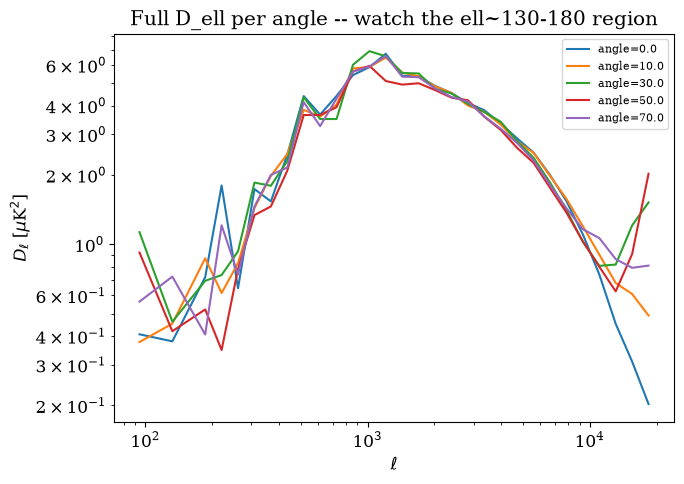

{0.0: 4.011130100742262, 10.0: 3.9241288268544787, 30.0: 3.9638638161726494, 50.0: 4.012697948703409, 70.0: 3.977909429356162}


In [14]:
d = np.load(f"{PRODUCTS_DIR}/convergence_angle_stitched.npz")
angles = d['angles']

fig, (ax2) = plt.subplots(1, 1, figsize=(7,5))
#ax1.plot(angles, d['D3000'], 'o-', color='tab:red')
#ax1.set_xlabel("angle_deg"); ax1.set_ylabel(r"$D_{3000}$ [$\mu$K$^2$]")
#ax1.set_title("D_3000 vs stitching angle")
#ax1.grid(alpha=0.3)

for i, a in enumerate(angles):
    ell = d[f'ell_{i}']; Dl = d[f'Dl_{i}']
    ax2.plot(ell, Dl, label=f'angle={a}')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel(r"$\ell$"); ax2.set_ylabel(r"$D_\ell$ [$\mu$K$^2$]")
ax2.set_title("Full D_ell per angle -- watch the ell~130-180 region")
ax2.legend(fontsize=8)
#ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/angle_convergence_combined.pdf", bbox_inches='tight')
plt.show()
print(dict(zip(angles, d['D3000'])))

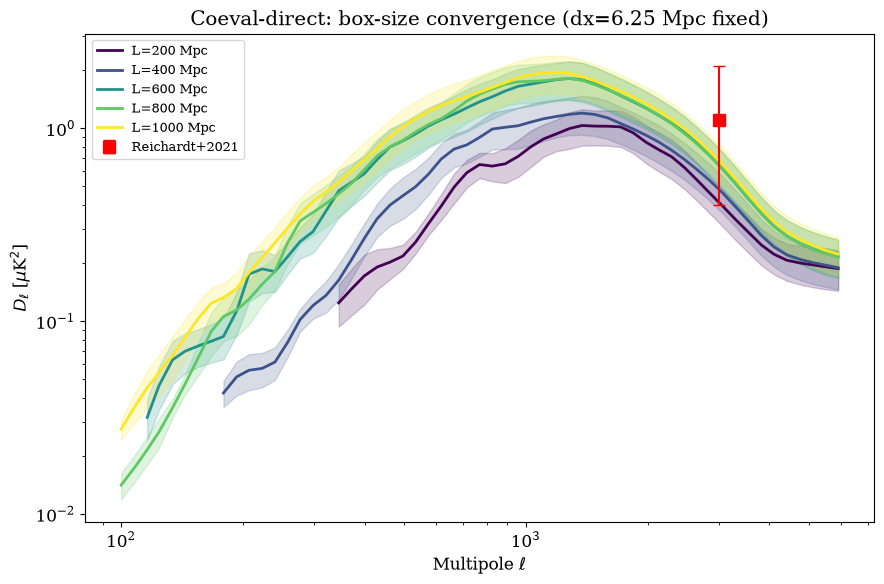

In [8]:
d = np.load(f"{PRODUCTS_DIR}/convergence_coeval_boxsize_full.npz")
tags, x_values = d['tags'], d['x_values']

fig, ax = plt.subplots(figsize=(9,6))
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(x_values), vmax=max(x_values))
for tag, L in zip(tags, x_values):
    ell, Dl, sigma = d[f'ell_{tag}'], d[f'Dl_{tag}'], d[f'sigma_{tag}']
    color = cmap(norm(L))
    ax.plot(ell, Dl, color=color, lw=2, label=f'L={L} Mpc')
    ax.fill_between(ell, Dl-sigma, Dl+sigma, color=color, alpha=0.2)
ax.errorbar([3000], [1.1], yerr=[[0.7],[1.0]], fmt='s', color='red', markersize=8, capsize=4, label='Reichardt+2021', zorder=10)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$D_\ell$ [$\mu$K$^2$]")
ax.set_title("Coeval-direct: box-size convergence (dx=6.25 Mpc fixed)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/Dell_boxsize_convergence_full.pdf", bbox_inches='tight')
plt.show()

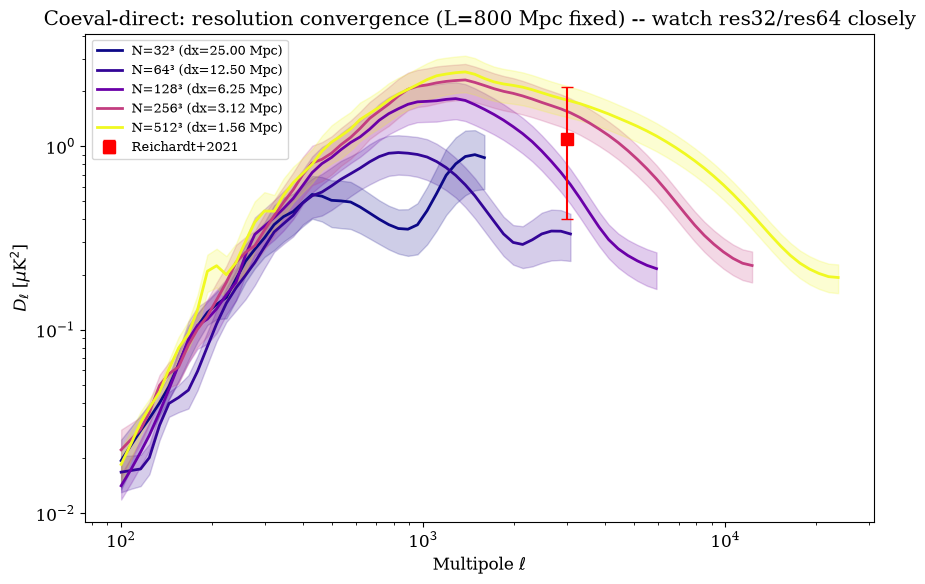

In [9]:
d = np.load(f"{PRODUCTS_DIR}/convergence_coeval_resolution_full.npz")
tags, x_values = d['tags'], d['x_values']

fig, ax = plt.subplots(figsize=(9,6))
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=min(x_values), vmax=max(x_values))
for tag, N in zip(tags, x_values):
    ell, Dl, sigma = d[f'ell_{tag}'], d[f'Dl_{tag}'], d[f'sigma_{tag}']
    color = cmap(norm(N))
    ax.plot(ell, Dl, color=color, lw=2, label=f'N={N}³ (dx={800/N:.2f} Mpc)')
    ax.fill_between(ell, Dl-sigma, Dl+sigma, color=color, alpha=0.2)
ax.errorbar([3000], [1.1], yerr=[[0.7],[1.0]], fmt='s', color='red', markersize=8, capsize=4, label='Reichardt+2021', zorder=10)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$D_\ell$ [$\mu$K$^2$]")
ax.set_title("Coeval-direct: resolution convergence (L=800 Mpc fixed) -- watch res32/res64 closely")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/Dell_resolution_convergence_full.pdf", bbox_inches='tight')
plt.show()

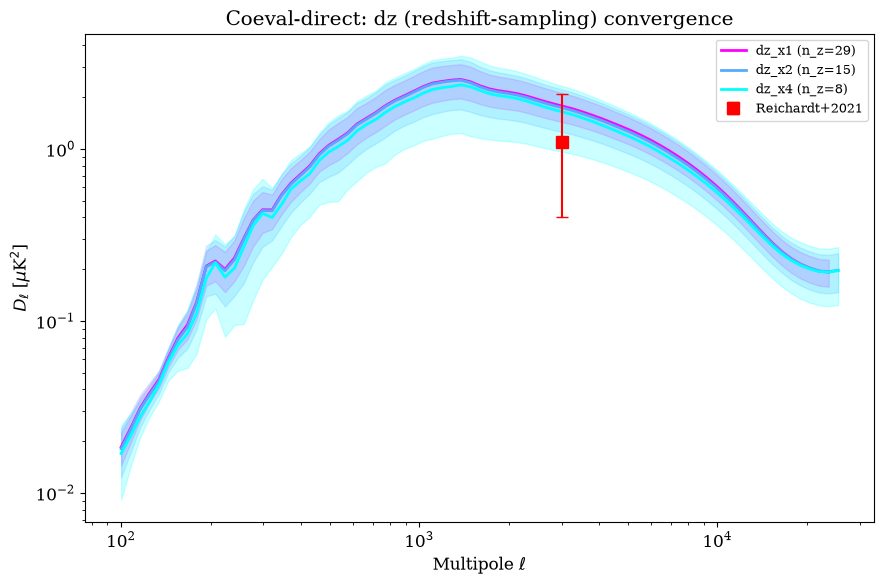

In [10]:
d = np.load(f"{PRODUCTS_DIR}/convergence_dz_coeval_full.npz")
tags, x_values = d['tags'], d['x_values']

fig, ax = plt.subplots(figsize=(9,6))
cmap = plt.cm.cool
norm = plt.Normalize(vmin=min(x_values), vmax=max(x_values))
for tag, n_z in zip(tags, x_values):
    ell, Dl, sigma = d[f'ell_{tag}'], d[f'Dl_{tag}'], d[f'sigma_{tag}']
    color = cmap(norm(n_z))
    ax.plot(ell, Dl, color=color, lw=2, label=f'{tag} (n_z={n_z})')
    ax.fill_between(ell, Dl-sigma, Dl+sigma, color=color, alpha=0.2)
ax.errorbar([3000], [1.1], yerr=[[0.7],[1.0]], fmt='s', color='red', markersize=8, capsize=4, label='Reichardt+2021', zorder=10)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$D_\ell$ [$\mu$K$^2$]")
ax.set_title("Coeval-direct: dz (redshift-sampling) convergence")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/Dell_dz_convergence_full.pdf", bbox_inches='tight')
plt.show()